In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, LineString, MultiPolygon
import seaborn as sns
import matplotlib.colors as mcolors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA

import duckdb as ddb
import os
import plotly.express as px
from IPython.display import display, HTML
import importlib
import pydeck as pdk
import random
import torch
from torch import nn
import torch.nn.functional as F
import pyarrow.parquet

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, top_k_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tqdm.notebook import tqdm
from IPython.display import clear_output


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
gdf = gpd.read_parquet("russia_rnd_selection_features.parquet")

In [4]:
m = gdf.head(10000).explore(column='height_ratio', cmap='RdYlGn')

m.save("sample.html")

In [6]:
def set_global_seed(seed: int) -> None:

    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    g = torch.Generator()
    g.manual_seed(seed)
    return g

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [7]:
df = pd.DataFrame(gdf.drop(columns=["id", "tags", "geometry", "tags", "levels", "oriented_mbr", "centroid", "representative_pt", "convex_hull", "inscribed_circle"]))
df

,type,level_count,area,area_MRR,length,width,perimeter,compactness,compactness_index,rectangularity,...,convex_vertex_ratio,inscribed_radius,inscribed_area_ratio,enclosed_radius,enclosed_area_ratio,circular_variance,floor_area,height_ratio,hole_count,normalized_centroid_offset
0,house,1,124.754012,131.023349,13.709490,9.557109,45.422888,2.746501,0.759827,0.952151,...,1.000000,4.707490,0.558051,8.355969,0.568736,0.563368,124.754012,0.241733,0,2.203645e-03
1,house,1,95.170453,95.459367,10.538953,9.058135,39.129676,2.432181,0.781087,0.996973,...,1.000000,4.529006,0.677101,6.948220,0.627488,0.651823,95.170453,0.276766,0,2.613005e-08
2,house,1,36.290994,36.304898,9.853755,3.684471,27.068754,1.340697,0.622404,0.999617,...,1.000000,1.842179,0.293775,5.260030,0.417515,0.350222,36.290994,0.448192,0,1.964995e-08
3,house,1,110.793858,123.043683,11.629317,10.580438,44.395790,2.495594,0.706386,0.900443,...,0.833333,4.617212,0.604497,7.850187,0.572276,0.588166,110.793858,0.256511,0,7.471459e-03
4,house,1,40.361529,42.202027,8.045073,5.246233,26.001849,1.552256,0.750186,0.956388,...,1.000000,2.587223,0.521015,4.802015,0.557148,0.538779,40.361529,0.424991,0,5.929608e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60673,gatehouse,2,19.930447,19.948791,4.498540,4.434503,17.857838,1.116062,0.785361,0.999080,...,1.000000,2.216371,0.774315,3.157248,0.636429,0.701994,39.860895,1.209582,0,5.537076e-05
60674,gatehouse,1,47.597723,77.480957,9.668042,8.018641,35.308528,1.348052,0.479774,0.614315,...,0.750000,2.714488,0.486340,6.278883,0.384301,0.432320,47.597723,0.391355,0,1.104201e-02
60675,gatehouse,1,20.569616,20.603339,5.827678,3.535256,18.710296,1.099374,0.738371,0.998363,...,1.000000,1.766802,0.476759,3.408251,0.563655,0.518389,20.569616,0.595320,0,1.642159e-04
60676,gatehouse,1,21.218375,21.266607,6.099838,3.486422,19.151854,1.107902,0.726943,0.997732,...,1.000000,1.741419,0.448998,3.509657,0.548319,0.496179,21.218375,0.586149,0,6.787202e-05


In [8]:
le = LabelEncoder()

encoded = le.fit_transform(df.iloc[:, 0])
label_to_name = {i: name for i, name in enumerate(le.classes_)}
label_to_name

{0: 'allotment_house',
 1: 'apartments',
 2: 'barn',
 3: 'bungalow',
 4: 'bunker',
 5: 'carport',
 6: 'chapel',
 7: 'church',
 8: 'civic',
 9: 'college',
 10: 'commercial',
 11: 'construction',
 12: 'cowshed',
 13: 'detached',
 14: 'dormitory',
 15: 'farm',
 16: 'farm_auxiliary',
 17: 'garage',
 18: 'garages',
 19: 'gatehouse',
 20: 'government',
 21: 'greenhouse',
 22: 'guardhouse',
 23: 'hangar',
 24: 'hospital',
 25: 'hotel',
 26: 'house',
 27: 'hut',
 28: 'industrial',
 29: 'kindergarten',
 30: 'kiosk',
 31: 'military',
 32: 'mosque',
 33: 'office',
 34: 'parking',
 35: 'pavilion',
 36: 'public',
 37: 'residential',
 38: 'retail',
 39: 'roof',
 40: 'ruins',
 41: 'school',
 42: 'semidetached_house',
 43: 'service',
 44: 'shed',
 45: 'storage_tank',
 46: 'terrace',
 47: 'train_station',
 48: 'transportation',
 49: 'university',
 50: 'warehouse'}

In [9]:
df_le = df.copy()
df_le['type'] = encoded
df_le

,type,level_count,area,area_MRR,length,width,perimeter,compactness,compactness_index,rectangularity,...,convex_vertex_ratio,inscribed_radius,inscribed_area_ratio,enclosed_radius,enclosed_area_ratio,circular_variance,floor_area,height_ratio,hole_count,normalized_centroid_offset
0,26,1,124.754012,131.023349,13.709490,9.557109,45.422888,2.746501,0.759827,0.952151,...,1.000000,4.707490,0.558051,8.355969,0.568736,0.563368,124.754012,0.241733,0,2.203645e-03
1,26,1,95.170453,95.459367,10.538953,9.058135,39.129676,2.432181,0.781087,0.996973,...,1.000000,4.529006,0.677101,6.948220,0.627488,0.651823,95.170453,0.276766,0,2.613005e-08
2,26,1,36.290994,36.304898,9.853755,3.684471,27.068754,1.340697,0.622404,0.999617,...,1.000000,1.842179,0.293775,5.260030,0.417515,0.350222,36.290994,0.448192,0,1.964995e-08
3,26,1,110.793858,123.043683,11.629317,10.580438,44.395790,2.495594,0.706386,0.900443,...,0.833333,4.617212,0.604497,7.850187,0.572276,0.588166,110.793858,0.256511,0,7.471459e-03
4,26,1,40.361529,42.202027,8.045073,5.246233,26.001849,1.552256,0.750186,0.956388,...,1.000000,2.587223,0.521015,4.802015,0.557148,0.538779,40.361529,0.424991,0,5.929608e-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60673,19,2,19.930447,19.948791,4.498540,4.434503,17.857838,1.116062,0.785361,0.999080,...,1.000000,2.216371,0.774315,3.157248,0.636429,0.701994,39.860895,1.209582,0,5.537076e-05
60674,19,1,47.597723,77.480957,9.668042,8.018641,35.308528,1.348052,0.479774,0.614315,...,0.750000,2.714488,0.486340,6.278883,0.384301,0.432320,47.597723,0.391355,0,1.104201e-02
60675,19,1,20.569616,20.603339,5.827678,3.535256,18.710296,1.099374,0.738371,0.998363,...,1.000000,1.766802,0.476759,3.408251,0.563655,0.518389,20.569616,0.595320,0,1.642159e-04
60676,19,1,21.218375,21.266607,6.099838,3.486422,19.151854,1.107902,0.726943,0.997732,...,1.000000,1.741419,0.448998,3.509657,0.548319,0.496179,21.218375,0.586149,0,6.787202e-05


In [10]:
X = df_le.iloc[:, 1:].astype('float64').values
y = df_le.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

X_train.shape, X_test.shape

((54623, 26), (6070, 26))

In [11]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

In [12]:
class GeoDataset(torch.utils.data.Dataset):
  def __init__(self, x, y):
    self.x = x
    self.y = y
  def __len__(self):
    return len(self.x)
  def __getitem__(self, idx):
    sample = torch.tensor(self.x[idx, :], dtype=torch.float)
    target = torch.tensor(self.y[idx], dtype=torch.int64)

    return sample, target

In [13]:
train_dataset = GeoDataset(X_train_sc, y_train)
val_dataset = GeoDataset(X_test_sc, y_test)

In [14]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 256, shuffle = True, worker_init_fn = seed_worker, generator = g)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size = 256, shuffle = False)

In [111]:
def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):

    epoch_train_loss = 0
    model.train()
    for objects, labels in tqdm(train_loader, desc=tqdm_desc):
      objects = objects.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      predictions = model(objects)
      loss = criterion(predictions, labels)
      loss.backward()
      optimizer.step()

      epoch_train_loss += loss.item() * objects.shape[0]

    epoch_train_loss /= len(train_loader.dataset)

    return epoch_train_loss


@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):

    epoch_val_loss = 0
    model.eval()
    all_preds = []
    all_labels = []
    for objects, labels in tqdm(val_loader, desc=tqdm_desc):
      objects = objects.to(device)
      labels = labels.to(device)

      predictions = model(objects)
      loss = criterion(predictions, labels)
      epoch_val_loss += loss.item() * objects.shape[0]

      preds = torch.argmax(predictions, dim=1)
      all_preds.append(preds.cpu())
      all_labels.append(labels.cpu())

    epoch_val_loss /= len(val_loader.dataset)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    epoch_val_f1 = f1_score(y_true, y_pred, average='macro')
    return epoch_val_loss, epoch_val_f1

@torch.no_grad()
def predict(model, data_loader):
    model.eval()
    all_outputs = []
    for objects, _ in data_loader:
        objects = objects.to(device)
        outputs = model(objects)
        all_outputs.append(outputs.cpu())
    return torch.cat(all_outputs, dim=0)


def plot_losses(epoch, epoch_train_losses, epoch_val_losses, epoch_val_f1_scores, train_loss):
  clear_output()
  fig, axes = plt.subplots(1, 2, figsize=(12, 7))
  axes[0].plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, label='train')
  axes[0].plot(range(1, len(epoch_val_losses) + 1), epoch_val_losses, label='validation')
  axes[0].set_xlabel('epoch')
  axes[0].set_ylabel(f'{train_loss}')
  axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  axes[0].grid()
  axes[0].legend()
  axes[0].set_title(f'{train_loss} на тренировочной и валидационной выборках')

  axes[1].plot(range(1, len(epoch_val_f1_scores) + 1), epoch_val_f1_scores, label='validation', color='green')
  axes[1].set_xlabel('epoch')
  axes[1].set_ylabel('Macro F1-score')
  axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  axes[1].grid()
  axes[1].legend()
  axes[1].set_title('Macro F1-score на валидационной выборке')
  plt.show()

  print(f'Эпоха {epoch}')
  print(f'{train_loss} на тренировочной выборке = {epoch_train_losses[-1]:.3f}')
  print(f'{train_loss} на валидационной выборке = {epoch_val_losses[-1]:.3f}')

def train(model, optimizer, criterion, train_loader, val_loader, epochs, train_loss_name):

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_f1_scores = []

    for i in range(1, epochs+1):
      epoch_train_loss = training_epoch(model, optimizer, criterion, train_loader, f'Training {i} epoch')
      epoch_val_loss, epoch_val_f1 = validation_epoch(model, criterion, val_loader, f'Validating {i} epoch')

      epoch_train_losses.append(epoch_train_loss)
      epoch_val_losses.append(epoch_val_loss)
      epoch_val_f1_scores.append(epoch_val_f1)

      plot_losses(i, epoch_train_losses, epoch_val_losses, epoch_val_f1_scores, train_loss_name)

In [112]:
class ClassificNet(nn.Module):
  def __init__(self, in_features, hidden_features, num_classes):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(in_features, hidden_features), #26 - 128
        nn.ReLU(),
        nn.Linear(hidden_features, hidden_features*4), #128 - 512
        nn.ReLU(),
        nn.Linear(hidden_features*4, hidden_features), #256 - 128
        nn.ReLU(),
        nn.Linear(hidden_features, num_classes) #128 - 51
    )

  def forward(self, x):
    return self.model(x)

In [115]:
in_features = X_train_sc.shape[1]
hidden_features = 128
num_classes = len(np.unique(y_train))

classification_model = ClassificNet(in_features, hidden_features, num_classes).to(device)
optimizer = torch.optim.Adam(classification_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

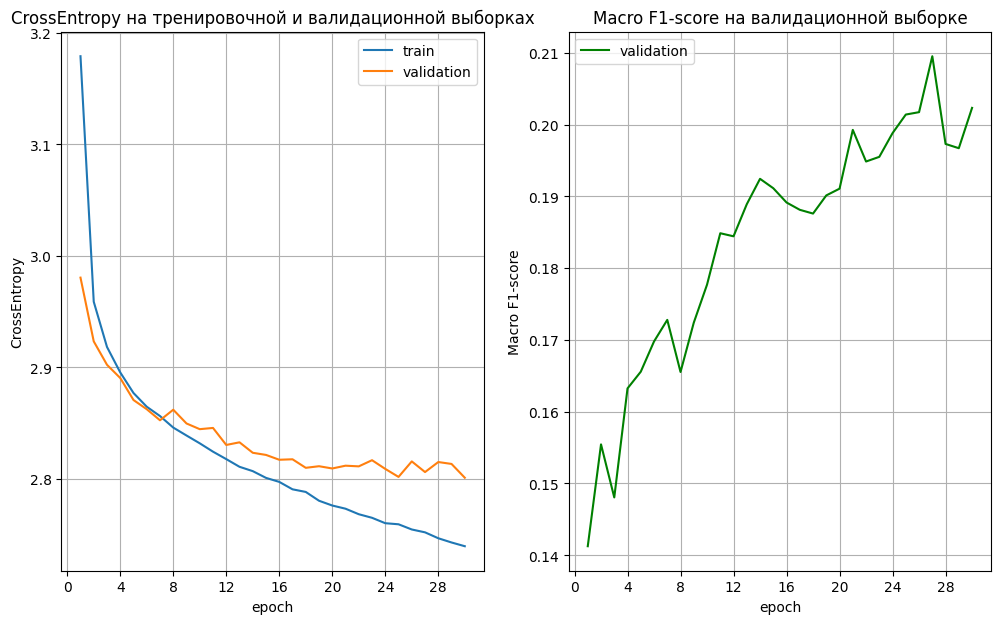

Эпоха 30
CrossEntropy на тренировочной выборке = 2.740
CrossEntropy на валидационной выборке = 2.801


In [116]:
train(model=classification_model, optimizer=optimizer, criterion=criterion, train_loader=train_loader, val_loader=val_loader, epochs=30, train_loss_name='CrossEntropy')

In [117]:
y_pred = torch.argmax(predict(classification_model, val_loader), dim=1)
y_pred

tensor([41, 44, 26,  ..., 42, 18,  8])

In [120]:
f1_score(y_test, y_pred, average='macro')

0.20232014194014686

In [121]:
accuracy_score(y_test, torch.argmax(predict(classification_model, val_loader), dim=1))

0.24398682042833608

In [122]:
top_k_accuracy_score(y_test, predict(classification_model, val_loader), k=3)

0.4456342668863262

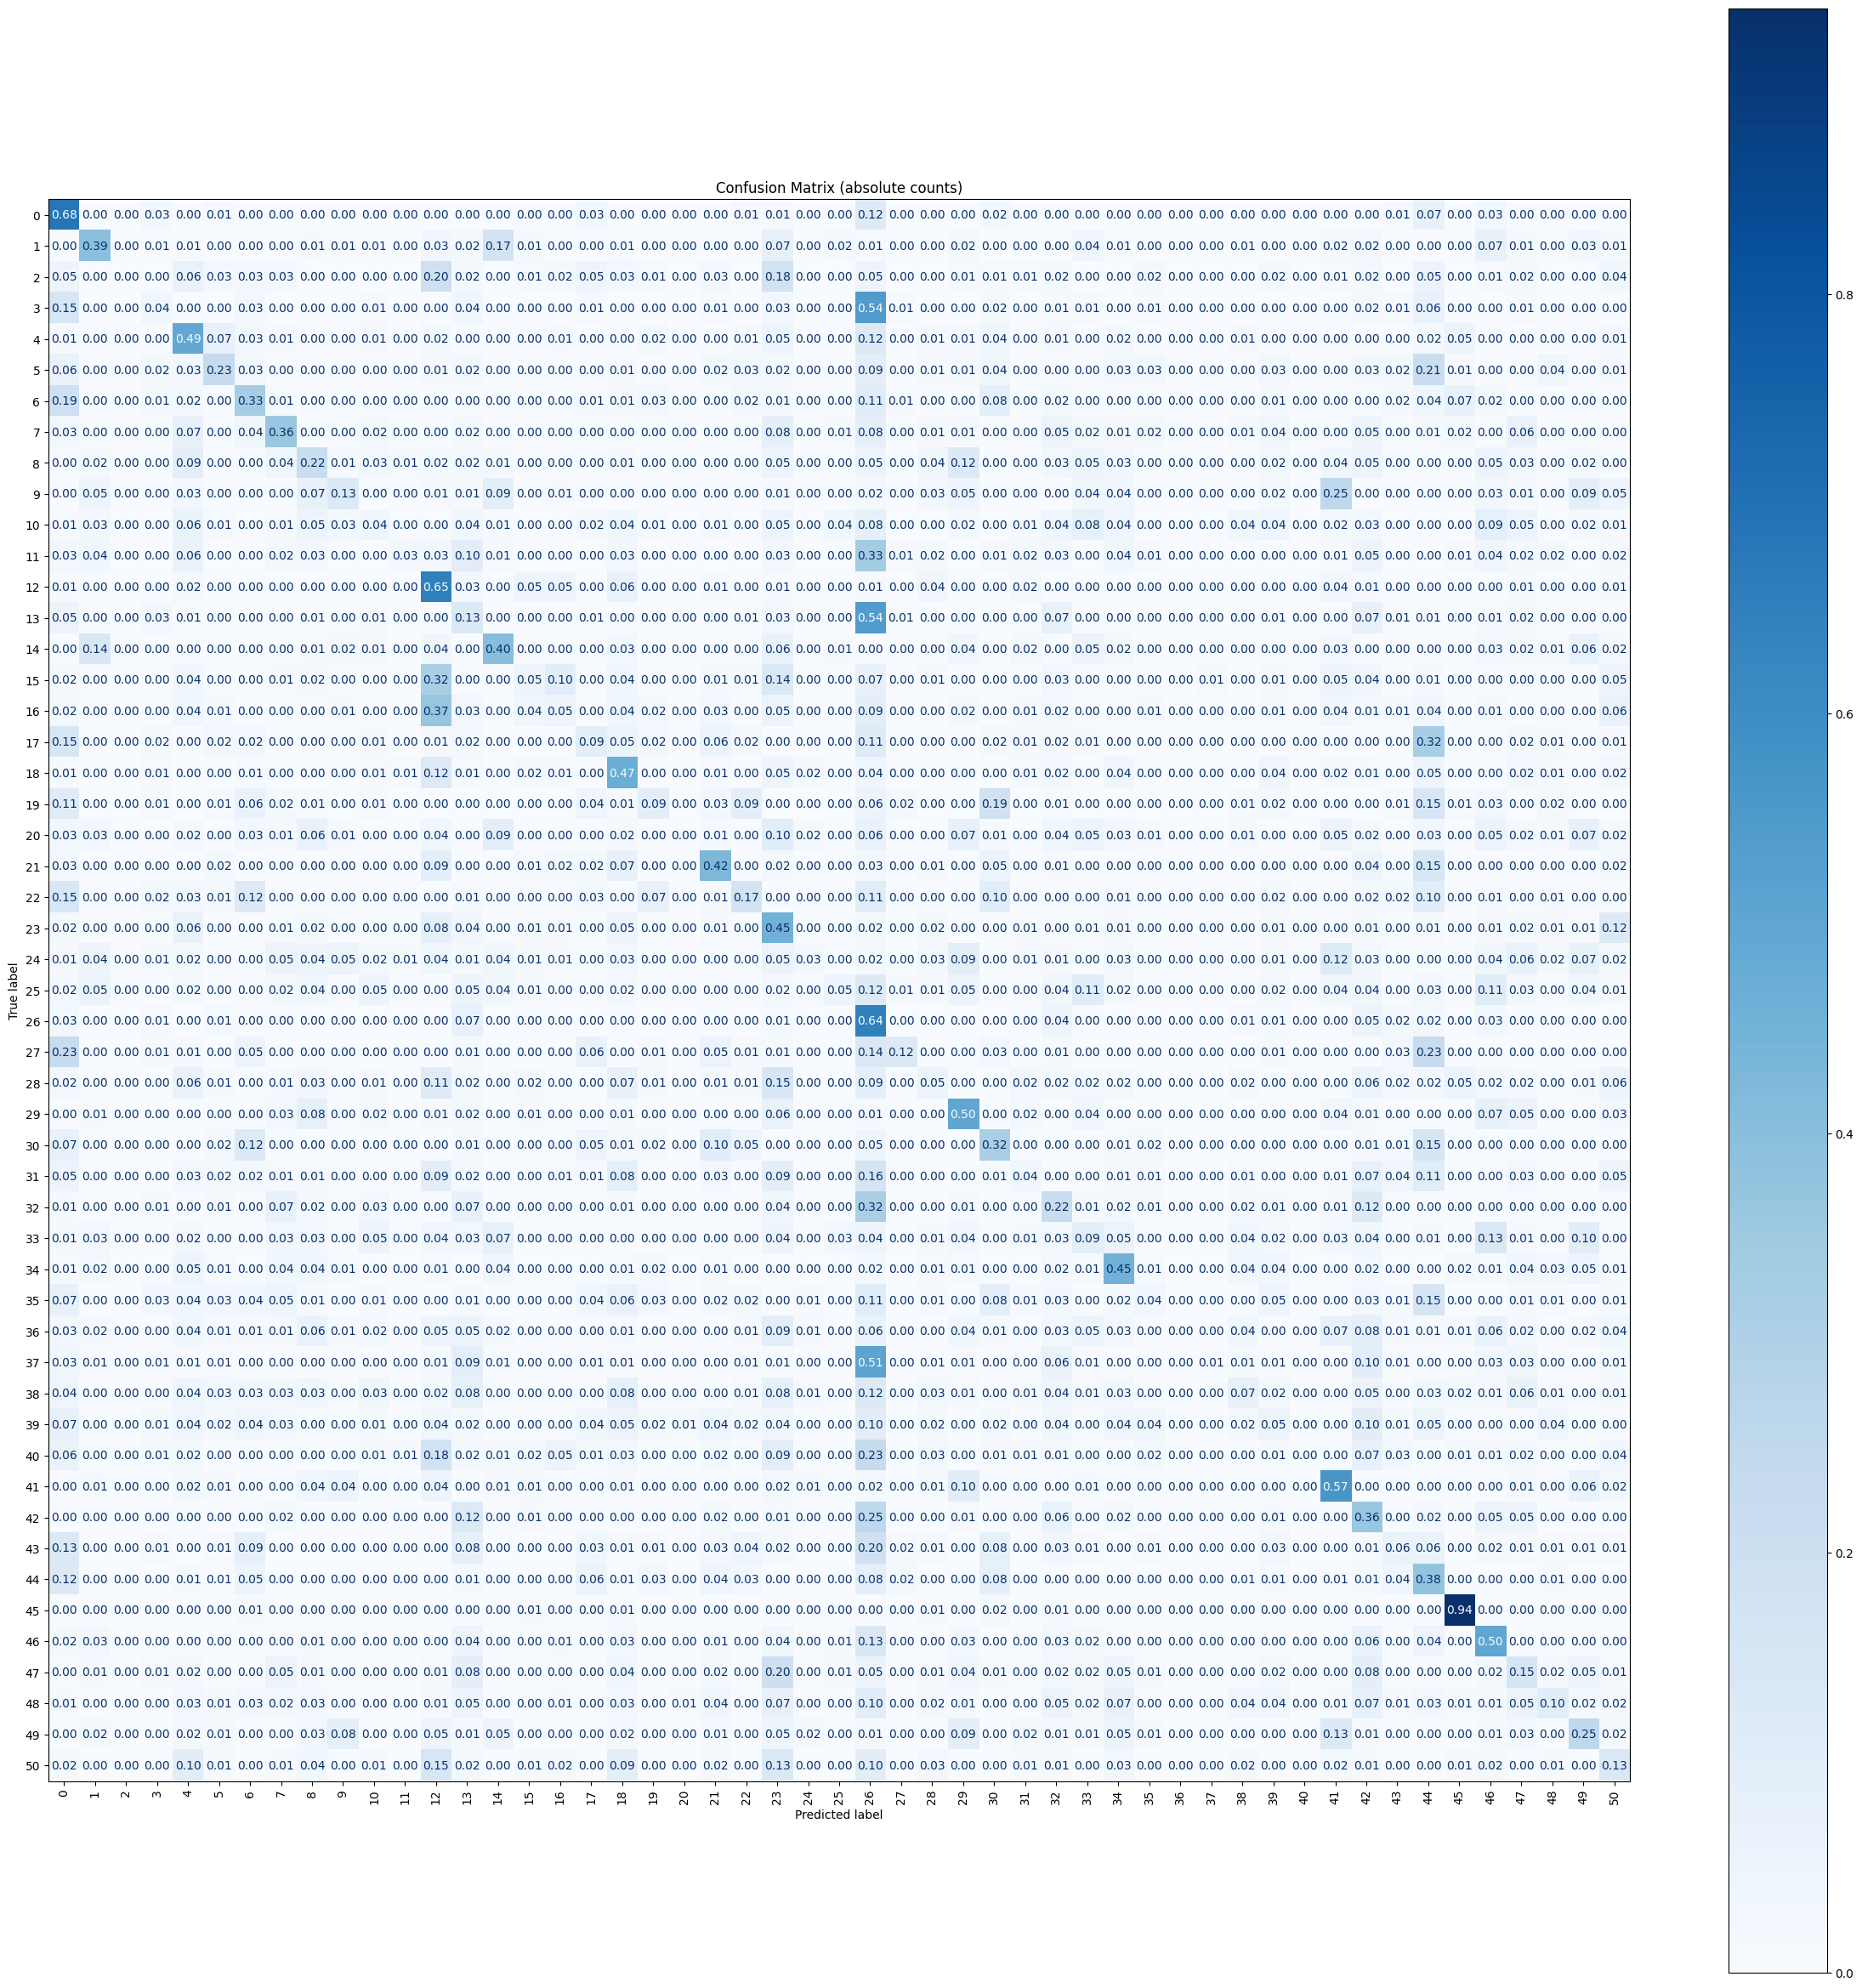

In [ ]:
cm = confusion_matrix(y_test, torch.argmax(predict(classification_model, val_loader), dim=1), normalize='true')

fig, ax = plt.subplots(figsize=(30,30))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues', xticks_rotation='vertical', values_format='.2f', ax=ax)
plt.title('Confusion Matrix (normalied)')
plt.show()

In [125]:
classification_model

ClassificNet(
  (model): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=51, bias=True)
  )
)

In [127]:
torch.save(classification_model.state_dict(), "model_trained.pt")